Lab 4

In session 3, we have used QuTiP to simulate a flux-tunable superconducting qubit and its interaction with a cavity. In this lab, we shall utilise the skills learnt in session 3 to a slightly more complex system which involves qubit-qubit interaction. Please familiarise yourself again with Jaynes-Cumming Model, flux-tunable qubits before you get on with this exercise.<br>

[Coupling superconducting qubits via a cavity bus](https://www.nature.com/articles/nature06184)

Import qutip and other packages

In [2]:
# setup the matplotlib graphics library and configure it to show 
# figures inline in the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt as sqrt
from numpy import pi as pi

# make qutip available in the rest of the notebook
from qutip import *

# Exercise 1: Multiplexed measurements

In a system where two qubits are coupled to the same cavity, show that the cavity is able to perform multiplexed measurements of the qubit states.

## System Hamiltonian

Create a system with the following hamiltonian:<br>
$H = \dfrac{\hbar\omega_{1}}{2}\sigma^z_1 + \dfrac{\hbar\omega_2}{2}\sigma^z_2 + \hbar\omega_{c}a^{\dagger}a + \hbar g_1\left(a^{\dagger}+a\right)\left(\sigma^{-}_1+\sigma^{+}_1\right) + \hbar g_2\left(a^{\dagger}+a\right)\left(\sigma^{-}_2+\sigma^{+}_2\right)$

In [3]:
fc = 2.0 * 2 * pi      # resonator frequency
fq1 = 3.0 * 2 * pi      # qubit frequency
fq2 = 3.5 * 2 * pi
g1 = 0.1 * 2 * pi   # parameter in the dispersive hamiltonian
g2 = 0.1 * 2 * pi
N = 15              # number of fock states

Type your codes here

In [4]:
# Operators
a = tensor(destroy(N), qeye(2), qeye(2))  # cavity annihilation
sm1 = tensor(qeye(N), destroy(2), qeye(2))  # qubit 1 lowering
sm2 = tensor(qeye(N), qeye(2), destroy(2))  # qubit 2 lowering

sz1 = tensor(qeye(N), sigmaz(), qeye(2))
sz2 = tensor(qeye(N), qeye(2), sigmaz())

# Qubit Hamiltonians
Hq1 = (fq1 / 2) * sz1
Hq2 = (fq2 / 2) * sz2

# Cavity Hamiltonian
Hc = fc * a.dag() * a

# Interaction Hamiltonian
Hint1 = g1 * (a + a.dag()) * (sm1 + sm1.dag())
Hint2 = g2 * (a + a.dag()) * (sm2 + sm2.dag())

# Total Hamiltonian
H = Hq1 + Hq2 + Hc + Hint1 + Hint2

## Cavity Spectrum

[QuTiP Lecture 10 - cQED Dispersive Limit](https://nbviewer.ipython.org/github/jrjohansson/qutip-lectures/blob/master/Lecture-10-cQED-dispersive-regime.ipynb)

Define your initial state here:

In [5]:
# States and their σ_z eigenvalues
states = {
    "|00⟩": (+1, +1),
    "|01⟩": (+1, -1),
    "|10⟩": (-1, +1),
    "|11⟩": (-1, -1),
}

# detuning and shift
delta_1 = fq1 - fc
delta_2 = fq2 - fc
kappa_1 = g1**2 / delta_1
kappa_2 = g2**2 / delta_2

# cavity decay
gamma = 0.005 * 2 * np.pi
c_ops = [np.sqrt(gamma) * a]

# drive amplitude
epsilon = 1e-3 * 2 * np.pi

# frequency sweep
freq_list = np.linspace(fc - 0.1 * 2 * np.pi, fc + 0.1 * 2 * np.pi, 200)

Check your cavity response in frequency domain:

In [6]:
# cavity response in frequency domain, for given z1, z2
def cavity_response(z1, z2):
    f_eff = fc + kappa_1 * z1 + kappa_2 * z2
    response = []
    for freq in freq_list:
        delta = f_eff - freq  # detuning in rotating frame
        H = delta * a.dag() * a + epsilon * (a + a.dag())
        psi_ss = steadystate(H, c_ops)  # steady state under collapse operator
        response.append(np.abs(expect(a, psi_ss)))  # output amplitude
    return np.array(response)

## Check how the cavity shifts relates to $\chi_1$ and $\chi_2$

Type your codes here:

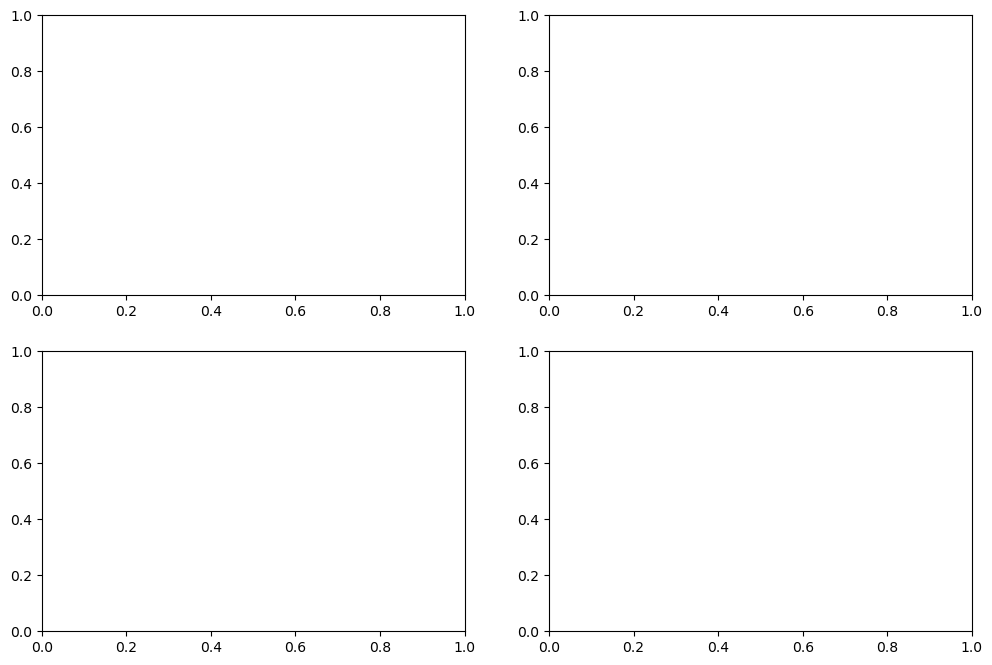

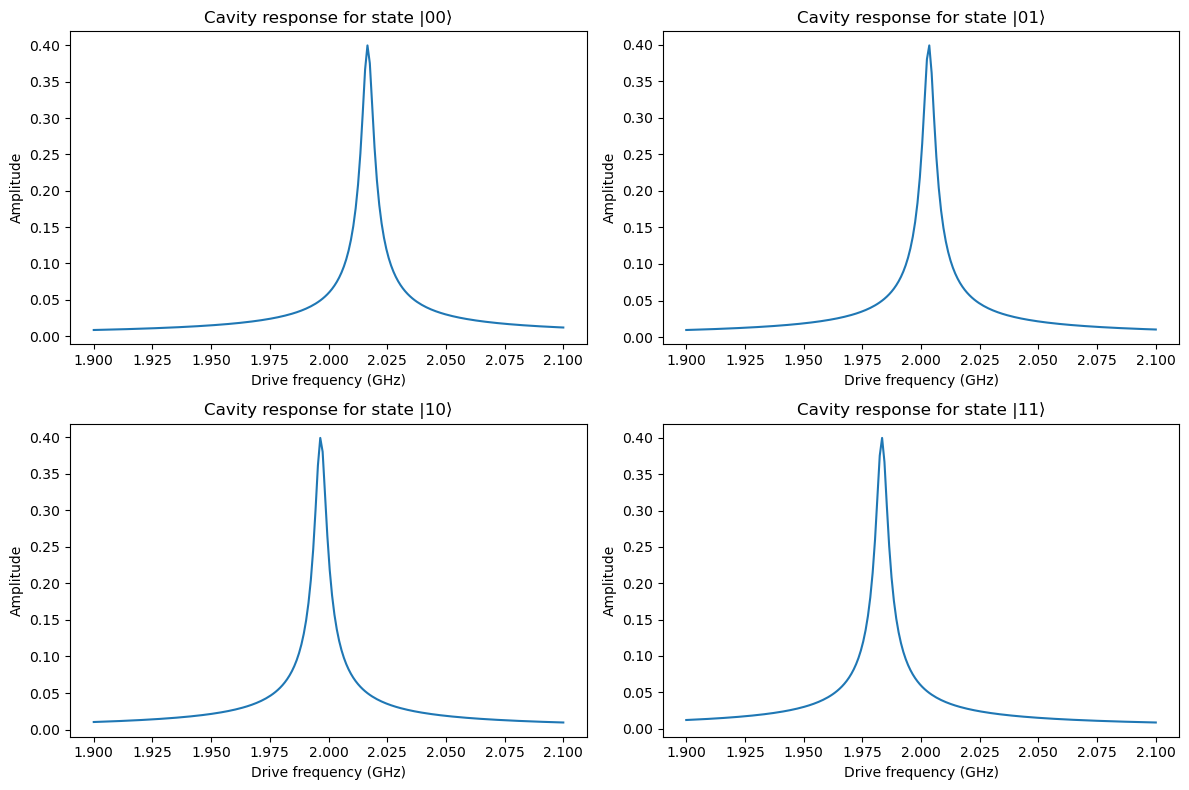

In [8]:
# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (label, (z1, z2)) in enumerate(states.items()):
    response = cavity_response(z1, z2)
    axs[i].plot(freq_list / (2 * np.pi), response)
    axs[i].set_title(f"Cavity response for state {label}")
    axs[i].set_xlabel("Drive frequency (GHz)")
    axs[i].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Exercise 2: Qubit-qubit interaction

Show that only when the two qubits are degenerate, an excitation in one qubit can be transferred to the other qubit through virtual exchange of photons with the cavity in the dispersive regime.

Define your system such that the two qubits are degenerate and operated in the dispersive regime:

Evolve your system and check if the two qubits exchange energy

Type your codes here:

Now detune your qubit frequency slightly and show that the qubit-qubit interaction can be turned off:

What happens if you are no longer in the dispersive regime such that the qubits have direct photon exchange with the cavity?

Type your codes here: